# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rcParams
rcParams["text.usetex"] = True

# Import dataset

* Import the ``cell_index`` from the training and test dataset.
* Purpose: to check if all cells have been evaluated.

## training cell_index

In [2]:
# Path to the DuckDB instance:
# "osbad/database/train_dataset_severson.db"
db_filepath = (
    Path.cwd()
    .parents[2]
    .joinpath("database","train_dataset_severson.db"))

# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_train_dataset_sv").fetchdf()

# Get the cell index of training dataset
unique_cell_index_train = df_duckdb["cell_index"].unique()
print(f"Unique cell index: {unique_cell_index_train}")

Unique cell index: ['2017-05-12_5_4C-50per_3C_CH13' '2017-05-12_5_4C-50per_3C_CH14'
 '2017-05-12_5_4C-60per_3C_CH15' '2017-05-12_5_4C-60per_3C_CH16'
 '2017-05-12_5_4C-70per_3C_CH17' '2017-05-12_5_4C-70per_3C_CH18'
 '2017-05-12_6C-40per_3C_CH25' '2017-05-12_6C-40per_3C_CH26'
 '2017-05-12_6C-50per_3C_CH27' '2017-05-12_6C-50per_3C_CH28'
 '2017-05-12_6C-60per_3C_CH29' '2017-05-12_6C-60per_3C_CH30'
 '2017-05-12_7C-40per_3C_CH37' '2017-05-12_7C-40per_3C_CH38'
 '2017-05-12_4C-80per_4C_CH5' '2017-05-12_4C-80per_4C_CH6'
 '2017-05-12_4_4C-80per_4_4C_CH7' '2017-05-12_5_4C-80per_5_4C_CH11'
 '2017-05-12_5_4C-80per_5_4C_CH12' '2017-05-12_3_6C-80per_3_6C_CH1'
 '2017-05-12_3_6C-80per_3_6C_CH2' '2017-05-12_3_6C-80per_3_6C_CH3'
 '2017-05-12_5_4C-40per_3_6C_CH19']


## test cell_index

In [3]:
# Load only the test dataset
db_filepath = str(
    Path.cwd()
    .parents[2]
    .joinpath("database","test_dataset_severson.db"))

# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all test dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_test_dataset_sv").fetchdf()

# Get the cell index of test dataset
unique_cell_index_test = df_duckdb["cell_index"].unique()
print(f"Unique cell index: {unique_cell_index_test}")

Unique cell index: ['2017-05-12_5_4C-40per_3_6C_CH20' '2017-05-12_5_4C-50per_3_6C_CH21'
 '2017-05-12_5_4C-50per_3_6C_CH22' '2017-05-12_5_4C-60per_3_6C_CH23'
 '2017-05-12_5_4C-60per_3_6C_CH24' '2017-05-12_6C-30per_3_6C_CH31'
 '2017-05-12_6C-30per_3_6C_CH32' '2017-05-12_6C-40per_3_6C_CH33'
 '2017-05-12_6C-40per_3_6C_CH34' '2017-05-12_6C-50per_3_6C_CH35'
 '2017-05-12_6C-50per_3_6C_CH36' '2017-05-12_7C-30per_3_6C_CH39'
 '2017-05-12_7C-30per_3_6C_CH40' '2017-05-12_7C-40per_3_6C_CH41'
 '2017-05-12_7C-40per_3_6C_CH42' '2017-05-12_8C-15per_3_6C_CH43'
 '2017-05-12_8C-15per_3_6C_CH44' '2017-05-12_8C-25per_3_6C_CH45'
 '2017-05-12_8C-25per_3_6C_CH46' '2017-05-12_8C-35per_3_6C_CH47'
 '2017-05-12_8C-35per_3_6C_CH48' '2017-05-12_4_8C-80per_4_8C_CH9'
 '2017-05-12_4_8C-80per_4_8C_CH10']


## Define metrics filepath

In [4]:
TRAIN_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "01_train_dataset",
    "eval_metrics_hp_single_cell_severson.csv")

VALIDATE_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "02_validation_dataset",
    "eval_metrics_severson_train_multiple_cells.csv")

TEST_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "03_test_dataset",
    "eval_metrics_severson_test_multiple_cells.csv")


# 01: Train on a single cell

* The models are trained and evaluated on the dataset from a single cell
* While all models have perfect accuracy, precision, recall, F1-score and MCC score from the training and evaluation based on a single cell, it also implies that the models could be overfitted.
* Therefore, it is important to consider how the models perform across the dataset from multiple cells.

## Plot evaluation metrics for a single cell

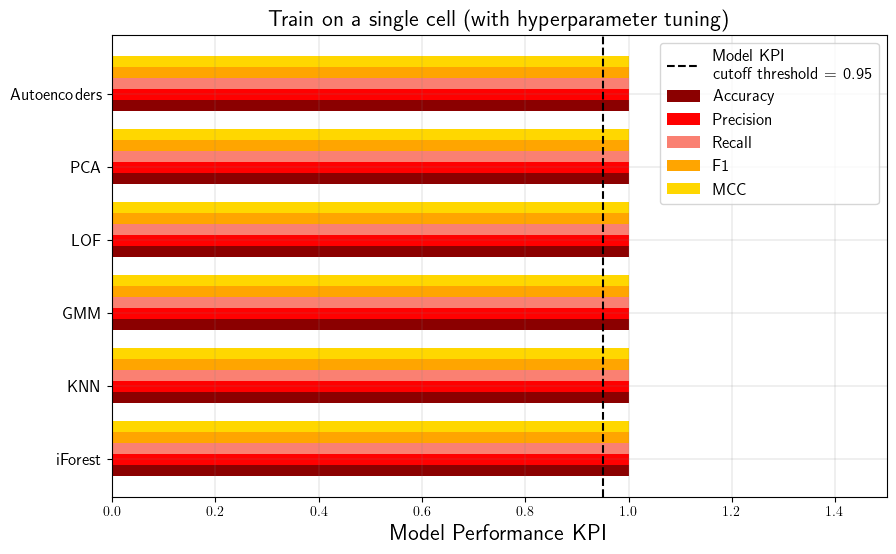

In [5]:
df_eval_metrics_train = pd.read_csv(TRAIN_DATASET_METRICS_PATH)

list_acc = df_eval_metrics_train["accuracy"].to_list()
list_precision = df_eval_metrics_train["precision"].to_list()
list_recall = df_eval_metrics_train["recall"].to_list()
list_f1 = df_eval_metrics_train["f1_score"].to_list()
list_mcc = df_eval_metrics_train["mcc_score"].to_list()

fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.15

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Train on a single cell (with hyperparameter tuning)",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_hp_single_cell.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 02: Validation across multiple cells

For the **hyperparameter tuning using the transfer learning method**:

* In the validation stage, the hyperparameter tuning is performed across 23 different cell experimental dataset.
* The best trial parameters are recorded for each model across all cells.
* The hyperparameters are subsequently averaged and transfer to the test dataset (another 23 cells).
* The corresponding model metrics are also recorded and then averaged to evaluate how each model performs across 23 different cell dataset during the validation stage.

## Drop duplicates in the training dataset

* Some metrics have been evaluated multiple times for the same ``ml_model`` and ``cell_index``
* ``df_eval_metrics_validate`` ensures that the combined ``ml_model`` and ``cell_index`` are unique

In [6]:
df_eval_metrics_validate = pd.read_csv(VALIDATE_DATASET_METRICS_PATH)

df_eval_metrics_validate = df_eval_metrics_validate.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")

## Check for missing ``cell_index``

* Check if any ``cell_index`` presents in the training dataset is missing in the evaluation dataset for all evaluated models.

In [7]:
unique_model_namelist = (
    df_eval_metrics_validate["ml_model"].unique())
print(f"Unique model name list: {unique_model_namelist}")

Unique model name list: ['iforest' 'knn' 'gmm' 'lof' 'pca' 'autoencoder']


In [8]:
total_cells_count_train = len(unique_cell_index_train)
print("Total cell count from the training dataset: " 
      + f"{total_cells_count_train}")

for selected_model_name in unique_model_namelist:

    df_selected_model = df_eval_metrics_validate[
        df_eval_metrics_validate["ml_model"] == selected_model_name]

    # -------------------------------------------------------------------------------
    # Get all unique cell index from the evaluation dataset
    training_eval_unique_cells = set(df_selected_model["cell_index"].unique())
    
    # cell_index that are in the training dataset, but not in the evaluation dataset
    diff_cell_index = set(unique_cell_index_train).difference(
        set(training_eval_unique_cells))
    
    # to check if all cells in the training cells have been evaluated for each model
    assert (len(diff_cell_index) == 0), (
        f"{selected_model_name} has missing cell index: {diff_cell_index}")

    # -------------------------------------------------------------------------------
    # To check that the number of evaluated cells also match the training dataset
    total_cells_count_eval = len(df_selected_model)

    assert (total_cells_count_eval == total_cells_count_train), (
        f"The number of evaluated cells does not match the training dataset")

Total cell count from the training dataset: 23


## Calculate average metrics

* Calculate the mean of ``accuracy``, ``precision``, ``recall``, ``f1_score`` and ``mcc_score`` across all evaluated cells in the training dataset.

In [9]:
eval_metrics_all_models_list = []

avg_accuracy_dict = {}
avg_precision_dict = {}
avg_recall_dict = {}
avg_f1_score_dict = {}
avg_mcc_dict = {}

for selected_model in df_eval_metrics_validate["ml_model"].unique():
    print(f"Evaluating {selected_model}")

    df_selected_model = (
        df_eval_metrics_validate[df_eval_metrics_validate["ml_model"] 
        == selected_model])

    avg_accuracy = np.mean(df_selected_model["accuracy"])
    print(f"Average accuracy: {avg_accuracy}")
    avg_accuracy_dict.update({selected_model: avg_accuracy})
    
    avg_precision = np.mean(df_selected_model["precision"])
    print(f"Average precision: {avg_precision}")
    avg_precision_dict.update({selected_model: avg_precision})
    
    avg_recall = np.mean(df_selected_model["recall"])
    print(f"Average recall: {avg_recall}")
    avg_recall_dict.update({selected_model: avg_recall})
    
    avg_f1_score = np.mean(df_selected_model["f1_score"])
    print(f"Average F1 score: {avg_f1_score}")
    avg_f1_score_dict.update({selected_model: avg_f1_score})
    
    avg_mcc_score = np.mean(df_selected_model["mcc_score"])
    print(f"Average MCC score: {avg_mcc_score}")
    avg_mcc_dict.update({selected_model: avg_mcc_score})
    
    print("-"*70)

    eval_dict = {
        "ml_model": selected_model,
        "avg_accuracy": [avg_accuracy],
        "avg_precision": [avg_precision],
        "avg_recall": [avg_recall],
        "avg_f1_score": [avg_f1_score],
        "avg_mcc_score": [avg_mcc_score]
    }
    
    df_eval_metrics_per_model = pd.DataFrame.from_dict(eval_dict)
    eval_metrics_all_models_list.append(df_eval_metrics_per_model)

Evaluating iforest
Average accuracy: 0.9998917890496959
Average precision: 0.991304347826087
Average recall: 0.9891304347826086
Average F1 score: 0.9889579020013803
Average MCC score: 0.9895370960056793
----------------------------------------------------------------------
Evaluating knn
Average accuracy: 0.9998909667680413
Average precision: 0.9891304347826086
Average recall: 0.9891304347826086
Average F1 score: 0.9875776397515529
Average MCC score: 0.9883026257929367
----------------------------------------------------------------------
Evaluating gmm
Average accuracy: 0.9995275524105469
Average precision: 0.991304347826087
Average recall: 0.9275362318840581
Average F1 score: 0.9439613526570049
Average MCC score: 0.950675454977903
----------------------------------------------------------------------
Evaluating lof
Average accuracy: 0.9999645653945644
Average precision: 1.0
Average recall: 0.991304347826087
Average F1 score: 0.9951690821256038
Average MCC score: 0.9953939759516041
--

In [10]:
df_compare_metrics = pd.concat(
    eval_metrics_all_models_list).reset_index(drop=True)

df_compare_metrics

,ml_model,avg_accuracy,avg_precision,avg_recall,avg_f1_score,avg_mcc_score
0,iforest,0.999892,0.991304,0.989130,0.988958,0.989537
1,knn,0.999891,0.989130,0.989130,0.987578,0.988303
2,gmm,0.999528,0.991304,0.927536,0.943961,0.950675
3,lof,0.999965,1.000000,0.991304,0.995169,0.995394
4,pca,0.999953,1.000000,0.989130,0.993789,0.994154
5,autoencoder,0.999953,1.000000,0.989130,0.993789,0.994154


## Plot evaluation metrics for all cells

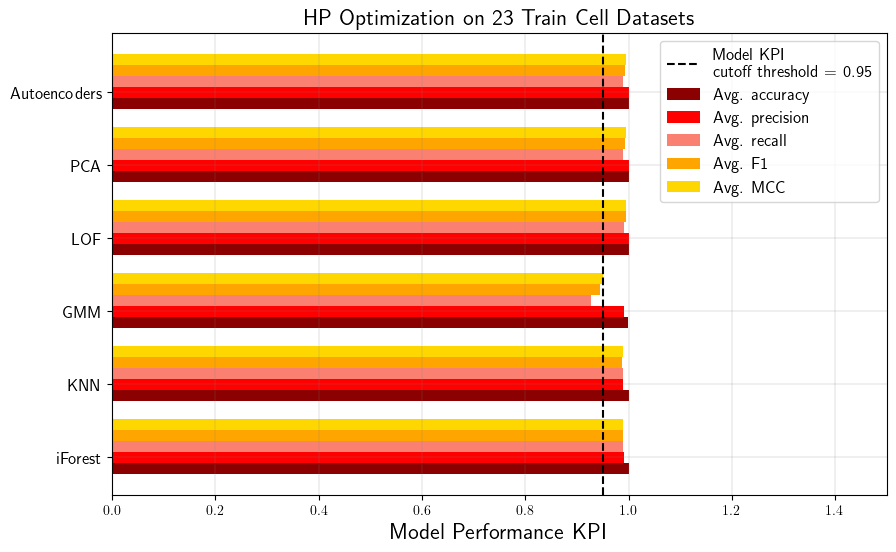

In [11]:
list_acc = df_compare_metrics["avg_accuracy"].to_list()
list_precision = df_compare_metrics["avg_precision"].to_list()
list_recall = df_compare_metrics["avg_recall"].to_list()
list_f1 = df_compare_metrics["avg_f1_score"].to_list()
list_mcc = df_compare_metrics["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "HP Optimization on 23 Train Cell Datasets",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_with_hp_multiple_cells_transfer_learning.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 03: Test across multiple cells

* No more hyperparameter tuning is performed during the test phase.
* The models are simply tested on the remaining 23 cells to evaluate how each model with the frozen hyperparameters generalize to new dataset.

## Drop duplicates in the test dataset

In [12]:
df_eval_metrics_test = pd.read_csv(TEST_DATASET_METRICS_PATH)

df_eval_metrics_test = df_eval_metrics_test.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")
df_eval_metrics_test

,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,iforest,2017-05-12_5_4C-40per_3_6C_CH20,1.000000,1.000000,1.00,1.000000,1.000000
1,iforest,2017-05-12_5_4C-50per_3_6C_CH21,1.000000,1.000000,1.00,1.000000,1.000000
2,iforest,2017-05-12_5_4C-50per_3_6C_CH22,0.998886,1.000000,0.75,0.857143,0.865541
3,iforest,2017-05-12_5_4C-60per_3_6C_CH23,1.000000,1.000000,1.00,1.000000,1.000000
4,iforest,2017-05-12_5_4C-60per_3_6C_CH24,1.000000,1.000000,1.00,1.000000,1.000000
...,...,...,...,...,...,...,...
133,autoencoder,2017-05-12_8C-25per_3_6C_CH46,1.000000,1.000000,1.00,1.000000,1.000000
134,autoencoder,2017-05-12_8C-35per_3_6C_CH47,1.000000,1.000000,1.00,1.000000,1.000000
135,autoencoder,2017-05-12_8C-35per_3_6C_CH48,1.000000,1.000000,1.00,1.000000,1.000000
136,autoencoder,2017-05-12_4_8C-80per_4_8C_CH9,0.997704,0.333333,1.00,0.500000,0.576686


## Check for missing ``cell_index``

In [13]:
unique_model_namelist = (
    df_eval_metrics_test["ml_model"].unique())
print(f"Unique model name list: {unique_model_namelist}")

Unique model name list: ['iforest' 'knn' 'gmm' 'lof' 'pca' 'autoencoder']


In [14]:
total_cells_count_test = len(unique_cell_index_test)
print("Total cell count from the testing dataset: " 
      + f"{total_cells_count_test}")

for selected_model_name in unique_model_namelist:
    print(f"Checking {selected_model_name}...")

    df_selected_model = df_eval_metrics_test[
        df_eval_metrics_test["ml_model"] == selected_model_name]

    # -------------------------------------------------------------------------------
    # Get all unique cell index from the evaluation dataset
    test_eval_unique_cells = set(df_selected_model["cell_index"].unique())
    
    # cell_index that are in the test dataset, but not in the evaluation dataset
    diff_cell_index = set(unique_cell_index_test).difference(
        set(test_eval_unique_cells))
    
    # to check if all cells in the testing cells have been evaluated for each model
    assert (len(diff_cell_index) == 0), (
        f"{selected_model_name} has missing cell index: {diff_cell_index}")

    # -------------------------------------------------------------------------------
    # To check that the number of evaluated cells also match the testing dataset
    total_cells_count_eval = len(df_selected_model)

    assert (total_cells_count_eval == total_cells_count_test), (
        f"The number of evaluated cells does not match the testing dataset")
    
print(f"All checks completed!")
print("*"*100)

Total cell count from the testing dataset: 23
Checking iforest...
Checking knn...
Checking gmm...
Checking lof...
Checking pca...
Checking autoencoder...
All checks completed!
****************************************************************************************************


## Calculate average metrics

In [15]:
test_eval_metrics_all_models_list = []

avg_accuracy_testdict = {}
avg_precision_testdict = {}
avg_recall_testdict = {}
avg_f1_score_testdict = {}
avg_mcc_testdict = {}

for selected_model in df_eval_metrics_test["ml_model"].unique():
    print(f"Evaluating {selected_model}")

    df_selected_model = (
        df_eval_metrics_test[df_eval_metrics_test["ml_model"] 
        == selected_model])

    avg_accuracy = np.mean(df_selected_model["accuracy"])
    print(f"Average accuracy: {avg_accuracy}")
    avg_accuracy_testdict.update({selected_model: avg_accuracy})
    
    avg_precision = np.mean(df_selected_model["precision"])
    print(f"Average precision: {avg_precision}")
    avg_precision_testdict.update({selected_model: avg_precision})
    
    avg_recall = np.mean(df_selected_model["recall"])
    print(f"Average recall: {avg_recall}")
    avg_recall_testdict.update({selected_model: avg_recall})
    
    avg_f1_score = np.mean(df_selected_model["f1_score"])
    print(f"Average F1 score: {avg_f1_score}")
    avg_f1_score_testdict.update({selected_model: avg_f1_score})
    
    avg_mcc_score = np.mean(df_selected_model["mcc_score"])
    print(f"Average MCC score: {avg_mcc_score}")
    avg_mcc_testdict.update({selected_model: avg_mcc_score})
    
    print("-"*70)

    eval_testdict = {
        "ml_model": selected_model,
        "avg_accuracy": [avg_accuracy],
        "avg_precision": [avg_precision],
        "avg_recall": [avg_recall],
        "avg_f1_score": [avg_f1_score],
        "avg_mcc_score": [avg_mcc_score]
    }
    
    df_eval_metrics_per_model = pd.DataFrame.from_dict(eval_testdict)
    test_eval_metrics_all_models_list.append(df_eval_metrics_per_model)

df_compare_metrics_test = pd.concat(
    test_eval_metrics_all_models_list).reset_index(drop=True)

df_compare_metrics_test

Evaluating iforest
Average accuracy: 0.9994289966267038
Average precision: 0.9231884057971014
Average recall: 0.9695652173913044
Average F1 score: 0.9338509316770186
Average MCC score: 0.9395924865605731
----------------------------------------------------------------------
Evaluating knn
Average accuracy: 0.999791729917507
Average precision: 0.967391304347826
Average recall: 0.991304347826087
Average F1 score: 0.9690821256038646
Average MCC score: 0.973606913575868
----------------------------------------------------------------------
Evaluating gmm
Average accuracy: 0.9993552608670223
Average precision: 0.9710144927536232
Average recall: 0.8775362318840579
Average F1 score: 0.9015182884748102
Average MCC score: 0.9122163276147013
----------------------------------------------------------------------
Evaluating lof
Average accuracy: 0.9992741319958982
Average precision: 0.9210144927536232
Average recall: 0.922463768115942
Average F1 score: 0.9041752933057282
Average MCC score: 0.91236

,ml_model,avg_accuracy,avg_precision,avg_recall,avg_f1_score,avg_mcc_score
0,iforest,0.999429,0.923188,0.969565,0.933851,0.939592
1,knn,0.999792,0.967391,0.991304,0.969082,0.973607
2,gmm,0.999355,0.971014,0.877536,0.901518,0.912216
3,lof,0.999274,0.921014,0.922464,0.904175,0.912361
4,pca,0.999696,0.971014,0.958696,0.954796,0.959441
5,autoencoder,0.999744,0.971014,0.969565,0.961008,0.965286


## Plot evaluation metrics

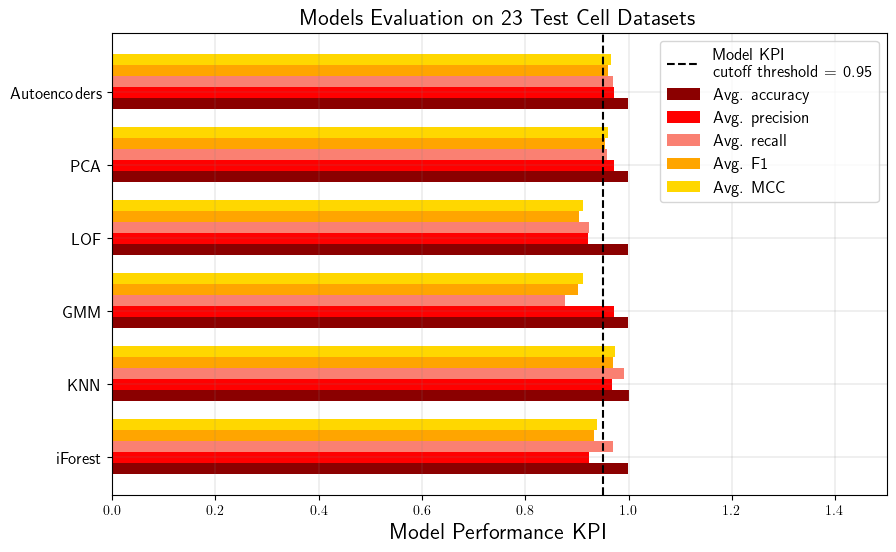

In [16]:
list_acc = df_compare_metrics_test["avg_accuracy"].to_list()
list_precision = df_compare_metrics_test["avg_precision"].to_list()
list_recall = df_compare_metrics_test["avg_recall"].to_list()
list_f1 = df_compare_metrics_test["avg_f1_score"].to_list()
list_mcc = df_compare_metrics_test["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Models Evaluation on 23 Test Cell Datasets",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_test_transfer_learning.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()